In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("../data/processed/diabetes_clean.csv")

print(df.shape)
df.head()

(101763, 30)


,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,...,glyburide,pioglitazone,rosiglitazone,insulin,glyburide-metformin,change,diabetesMed,readmitted,diag_1_grp,total_diabetes_meds
0,8222157,Caucasian,Female,5,6,25,1,1,41,0,...,0,0,0,0,0,No,No,0,Diabetes,0
1,55629189,Caucasian,Female,15,1,1,7,3,59,0,...,0,0,0,1,0,Ch,Yes,0,Other,1
2,86047875,AfricanAmerican,Female,25,1,1,7,2,11,5,...,0,0,0,0,0,No,Yes,0,Other,1
3,82442376,Caucasian,Male,35,1,1,7,2,44,1,...,0,0,0,1,0,Ch,Yes,0,Other,1
4,42519267,Caucasian,Male,45,1,1,7,1,51,0,...,0,0,0,1,0,Ch,Yes,0,Neoplasms,2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101763 entries, 0 to 101762
Data columns (total 30 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   patient_nbr               101763 non-null  int64 
 1   race                      101763 non-null  object
 2   gender                    101763 non-null  object
 3   age                       101763 non-null  int64 
 4   admission_type_id         101763 non-null  int64 
 5   discharge_disposition_id  101763 non-null  int64 
 6   admission_source_id       101763 non-null  int64 
 7   time_in_hospital          101763 non-null  int64 
 8   num_lab_procedures        101763 non-null  int64 
 9   num_procedures            101763 non-null  int64 
 10  num_medications           101763 non-null  int64 
 11  number_outpatient         101763 non-null  int64 
 12  number_emergency          101763 non-null  int64 
 13  number_inpatient          101763 non-null  int64 
 14  numb

In [4]:
df_eda = df.drop(columns=["patient_nbr"])

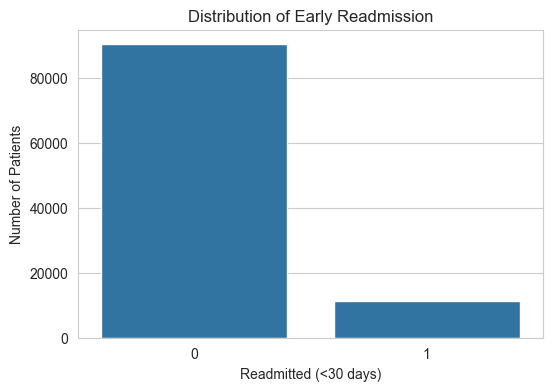

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x="readmitted", data=df_eda)

plt.title("Distribution of Early Readmission")
plt.xlabel("Readmitted (<30 days)")
plt.ylabel("Number of Patients")

plt.show()

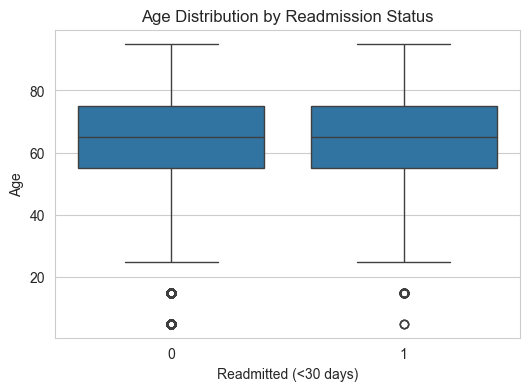

In [6]:
plt.figure(figsize=(6,4))

sns.boxplot(x="readmitted", y="age", data=df_eda)

plt.title("Age Distribution by Readmission Status")
plt.xlabel("Readmitted (<30 days)")
plt.ylabel("Age")

plt.show()

The distribution of age across readmission groups is very similar, indicating that age alone may not be a strong predictor of early hospital readmission in this dataset.

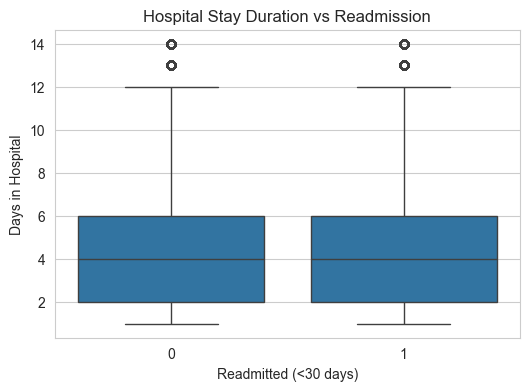

In [7]:
plt.figure(figsize=(6,4))

sns.boxplot(x="readmitted", y="time_in_hospital", data=df_eda)

plt.title("Hospital Stay Duration vs Readmission")
plt.xlabel("Readmitted (<30 days)")
plt.ylabel("Days in Hospital")

plt.show()

The distribution of hospital stay duration is similar for both readmission groups, suggesting that the number of days spent in hospital may not strongly differentiate early readmitted patients.

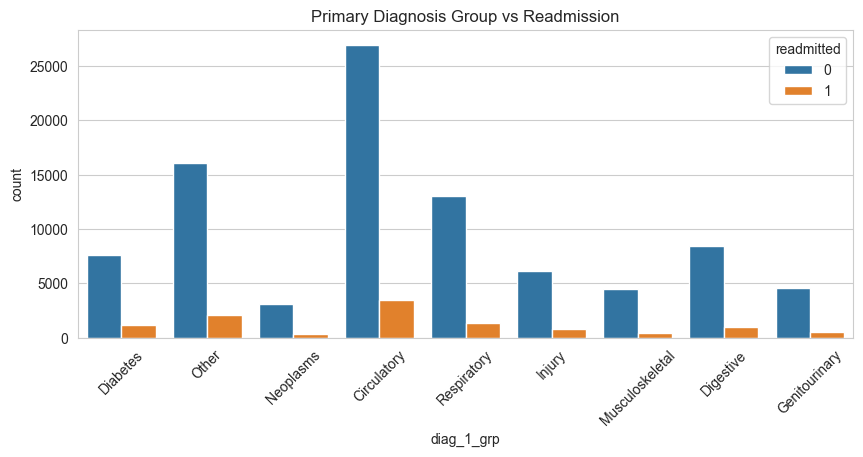

In [8]:
plt.figure(figsize=(10,4))

sns.countplot(x="diag_1_grp", hue="readmitted", data=df_eda)

plt.xticks(rotation=45)
plt.title("Primary Diagnosis Group vs Readmission")

plt.show()

The most common diagnosis category in the dataset is circulatory diseases. This group also exhibits the largest number of early readmissions. Respiratory and digestive conditions also show notable readmission counts, suggesting that disease category may influence the likelihood of hospital readmission.

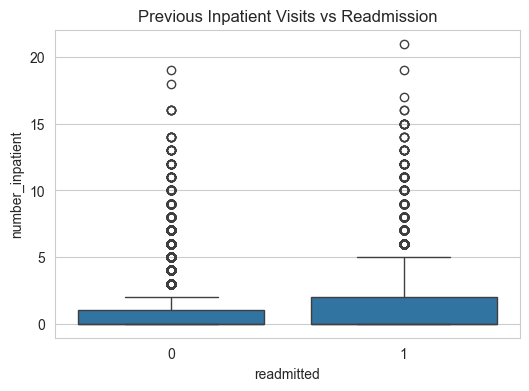

In [9]:
plt.figure(figsize=(6,4))

sns.boxplot(x="readmitted", y="number_inpatient", data=df_eda)

plt.title("Previous Inpatient Visits vs Readmission")
plt.show()

Patients who experienced early hospital readmission tend to have a higher number of previous inpatient visits. This suggests that prior hospitalization history may be an important predictor of future readmission risk.

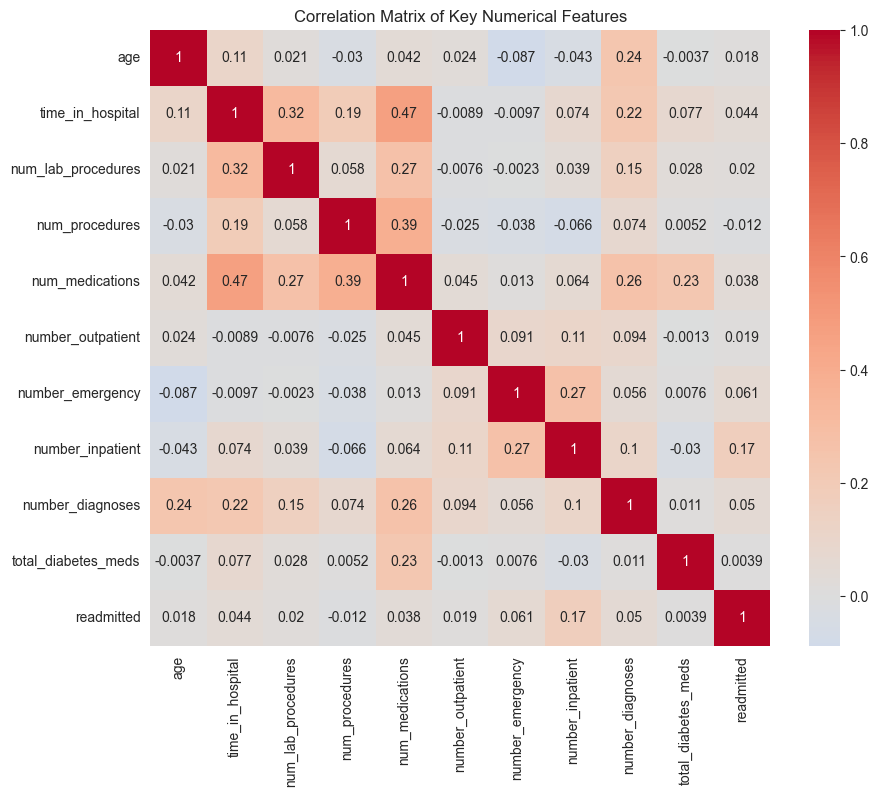

In [13]:
selected_cols = [
    "age",
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
    "total_diabetes_meds",
    "readmitted"
]

corr = df_eda[selected_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True)
plt.title("Correlation Matrix of Key Numerical Features")
plt.show()

The number of previous inpatient visits shows the strongest correlation with early readmission, suggesting that patients with a history of hospitalization are more likely to be readmitted.

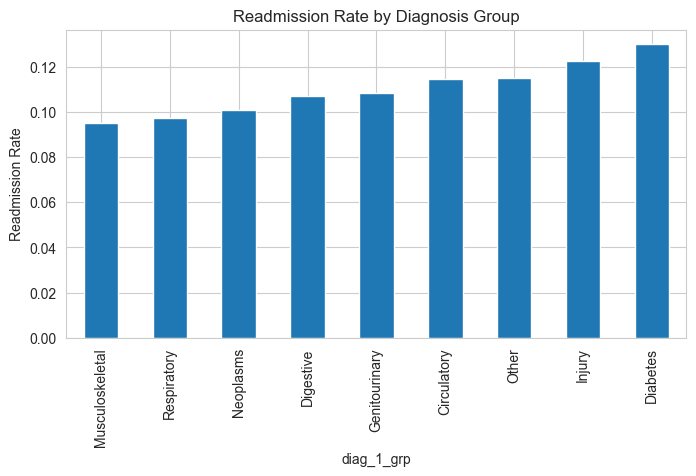

In [14]:
readmission_rate = df_eda.groupby("diag_1_grp")["readmitted"].mean().sort_values()

plt.figure(figsize=(8,4))
readmission_rate.plot(kind="bar")

plt.ylabel("Readmission Rate")
plt.title("Readmission Rate by Diagnosis Group")
plt.show()

The analysis shows that patients diagnosed with diabetes, injuries, or circulatory diseases exhibit higher early readmission rates compared to other diagnosis groups.